# Running ViMeMo by adjusting parameters at every step

This runner notebook lets us adjust the necessary parameters at each stage to create a point cloud representing the viral membrane and study its morphometrics. All reusable code lives in `vimemo/`.

In [1]:
from vimemo import (
    ModelMask,
    CryoEMSurvey,
    MaximaModel,
    MembraneMorphometry,
    load_mrc_map,
    plot_membrane_hammer,
    plot_model_mask_hammer,
)


## Load Map and Model

This section loads the raw cryo-EM density map from disk, together with any model-derived maps we may later want to use for contour overlays or for defining angular limits.

In [2]:
cryo_em_map = load_mrc_map("data/refine_job120_postcleaned_ctf.mrc")
trisym_map = load_mrc_map("data/3sym_on_icos.mrc")
pentasym_map = load_mrc_map("data/5sym_on_icos.mrc")
asu_map = load_mrc_map("data/asu_on_icos.mrc")
penfu1_map = load_mrc_map("data/penfu1_on_icos.mrc")
penfu2_map = load_mrc_map("data/penfu2_on_icos.mrc")

### Model Mask

We want to center our analysis on a segment of the membrane. A good indication for this would be where we have a model. If we create a onesmask out of our model in the same grid as our Surveyed Map, so we can import them here and see their limits. We can also use the same object to visualise their footprint in the final plots

In [3]:
trisym_mask = ModelMask(trisym_map, pixel_size=3.026)
pentasym_mask = ModelMask(pentasym_map, pixel_size=3.026)
asu_mask = ModelMask(asu_map, pixel_size=3.026)
penfu1_mask = ModelMask(penfu1_map, pixel_size=3.026)
penfu2_mask = ModelMask(penfu2_map,pixel_size=3.026)


In [4]:
trisym_mask.print_spherical_limits()

Spherical limits:
rho: 732.384 to 853.014 A
theta: 15.876 to 136.340 deg
phi: 108.479 to 162.420 deg


In [5]:
pentasym_mask.print_spherical_limits()

Spherical limits:
rho: 773.572 to 917.396 A
theta: 106.716 to 153.774 deg
phi: 120.462 to 152.237 deg


## CryoEMSurvey

`CryoEMSurvey` defines the radial and angular sampling of the cryo-EM map. In this section we instantiate the survey with the map, pixel size, survey radii, and angular limits, then generate the direction vectors and sample the raw density data along each direction.

In [6]:
survey = CryoEMSurvey(
    cryo_em_map=cryo_em_map,
    angspix=3.026,
    survey_radius_min_angst=600,
    survey_radius_angst=900,
    grid_theta_min_deg=5,
    grid_theta_max_deg=170,
    grid_phi_min_deg=103,
    grid_phi_max_deg=175,
)


In [7]:
survey.calculate_direction_vectors_angst(angle_step_deg=0.2)
survey.calculate_raw_density_data()

Generating grid (theta = 5.00 --> 170.00, phi = 103.00 --> 175.00).
Number of direction vectors generated: 298186
Raw density data calculated!


## MaximaModel

`MaximaModel` turns the surveyed density profiles into peak candidates. In this section we run the filtering steps used to isolate the membrane maxima. 

If at any point we want to restart this stage from the original detected peaks, we can use `maxima_model.recover_initial_maxima_model()`.

In [8]:
maxima_model = MaximaModel(survey=survey, peak_filter=0.01)


In the next cell we cluster the peaks by intensity and distance from the centre. All the membrane will be at a similar region, but will still include some noise afterwards, so further cleaning steps will be needed. 

2926258.9656426637


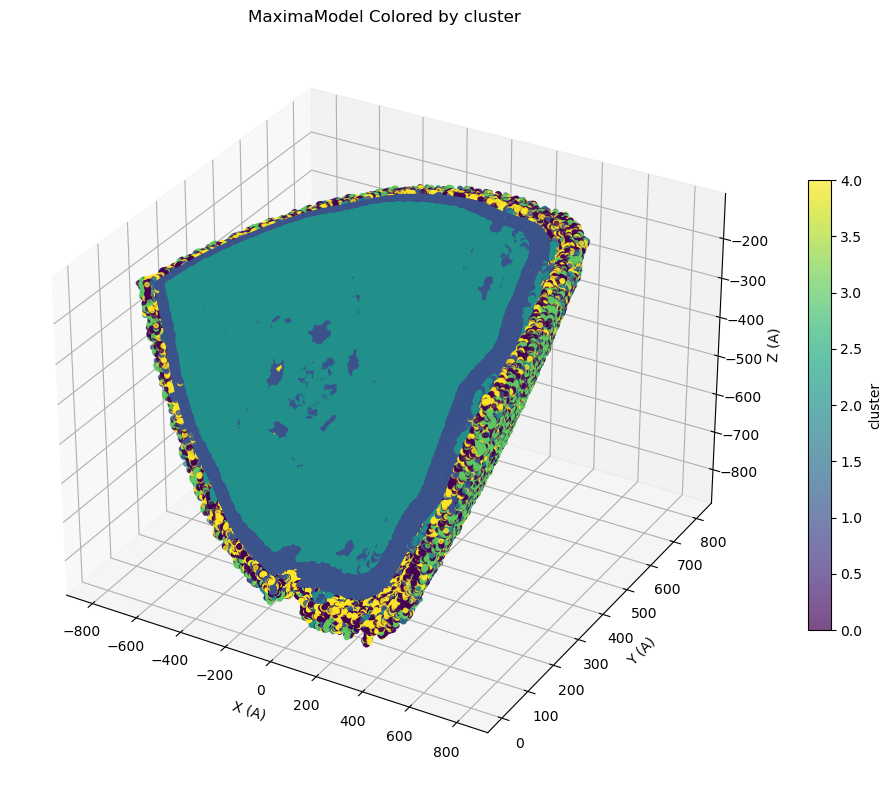

In [9]:
maxima_model.initial_k_clustering(amount_of_clusters=5)
maxima_model.static_plot(color_by="cluster")


Select the cluster to which the membrane is part of

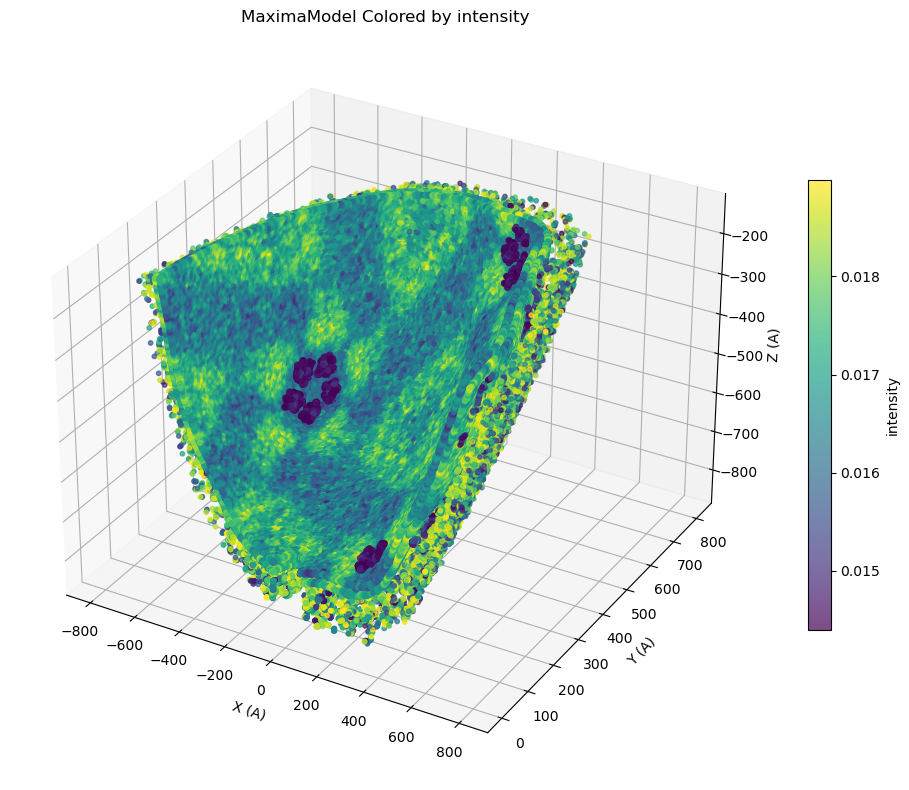

In [10]:
maxima_model.select_cluster(1)
maxima_model.static_plot(color_by="intensity")

Real membrane points should occupy spatially connected regions, while noise is often more isolated. `voxel_connection(...)` groups points by first placing them into a 3D voxel grid and then finding connected voxel components. The goal of this step is to keep the main membrane structure and suppress disconnected signal.

Key options in this step:
- `voxel_size`: the edge length of the voxel grid. Smaller values give a finer grid and stricter connectivity; larger values merge points more aggressively.
- `connectivity`: how neighboring voxels are defined. Use `"6"` for face-sharing neighbors only, `"18"` to also include edge-sharing neighbors, and `"26"` to include face-, edge-, and corner-sharing neighbors.
- `expected_structure_count`: how many large connected components you expect to keep.
- `min_neighbor_voxel_count`: minimum number of neighboring occupied voxels required for a voxel to be considered supported. Larger values make the filter stricter.

In practice, this step is exploratory: if the membrane gets fragmented, try increasing `voxel_size` or relaxing connectivity; if too much noise survives, try decreasing `voxel_size`, lowering `expected_structure_count`, or increasing `min_neighbor_voxel_count`.

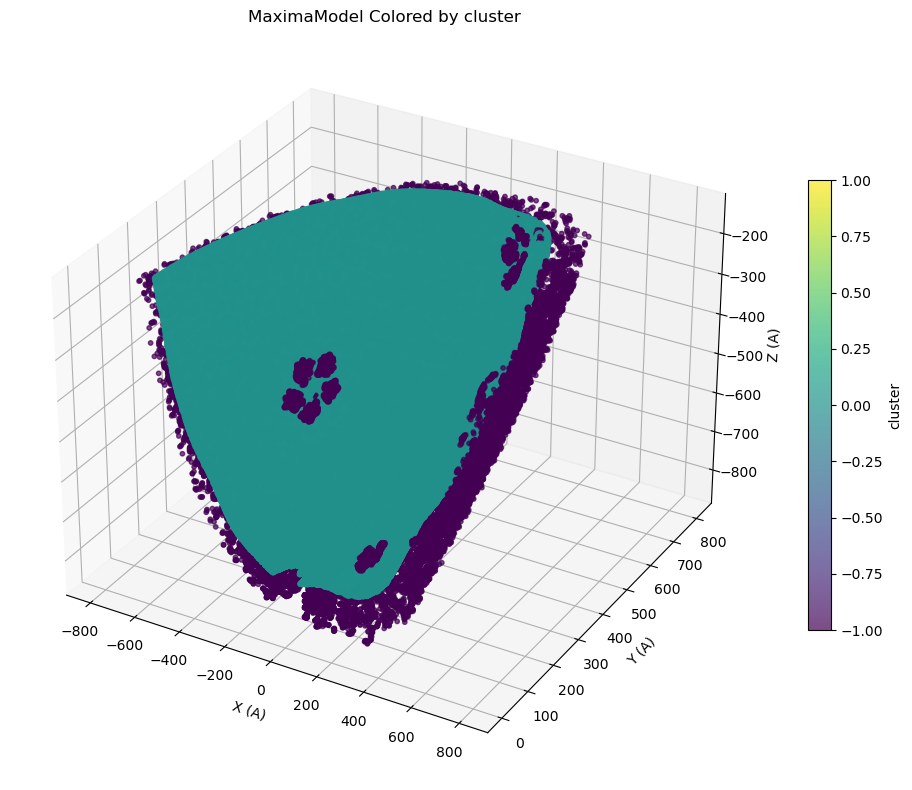

In [11]:
maxima_model.voxel_connection(
    voxel_size=5.5,
    connectivity="6",
    expected_structure_count=2,
    min_neighbor_voxel_count=1,
)
maxima_model.static_plot(color_by="cluster")

Directions with more than 2 points: 9
Directions with 1 point are kept: 8351


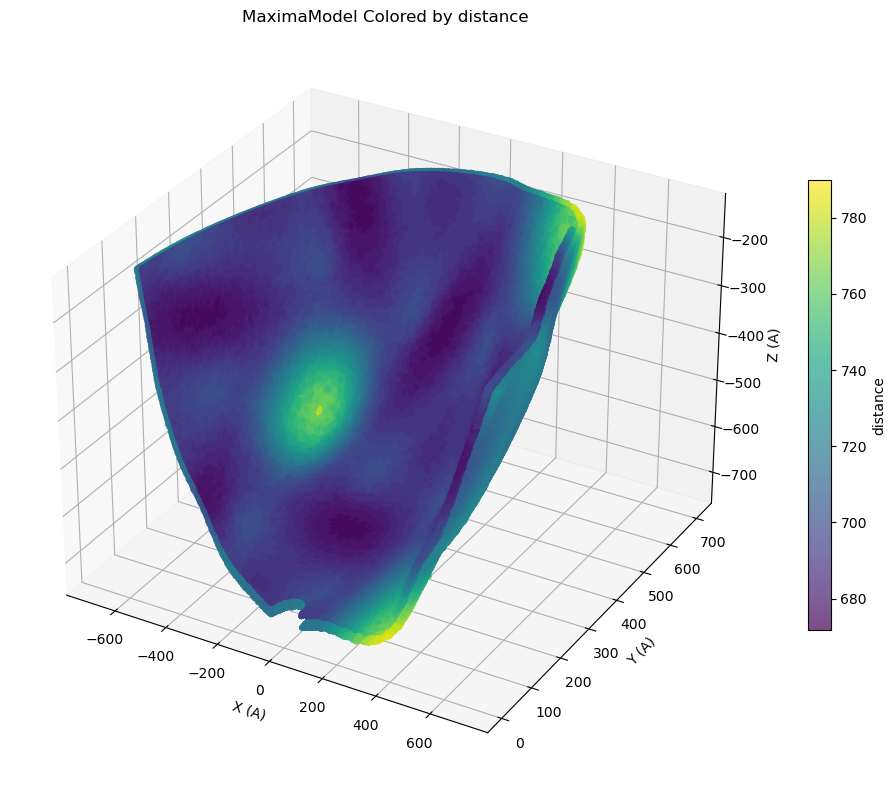

In [12]:
maxima_model.select_cluster(0)
maxima_model.cleanup_per_direction()
maxima_model.static_plot(color_by="distance")

## MembraneMorphometry

`MembraneMorphometry` takes the (almost) cleaned maxima model and adds membrane-specific structure: leaflet assignment,  spacing, and curvature. In the following sections we first create the membrane model and inspect leaflet assignment, then diagnose and remove outliers, and finally calculate the morphometrics.

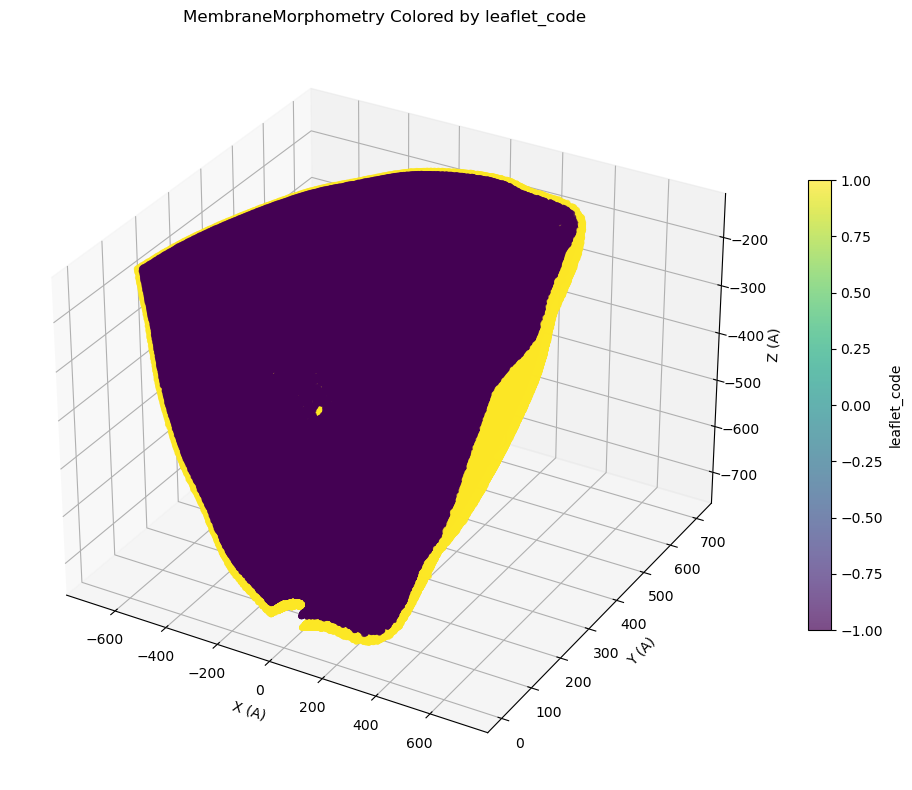

In [13]:
membrane = MembraneMorphometry.from_maxima_model(maxima_model)
membrane.static_plot(color_by="leaflet_code")

### Outlier Diagnosis

While we have done cleaning at the membrane level, in this section we will clean at the leaflet level. Here it flags spatial outliers within each leaflet. The idea is to inspect the outlier calls before removing them, so the threshold remains exploratory and adjustable from the notebook. You can adjust `sd_multiplier` to make the outlier detection more strict (lower SD multiplier) or relaxed (higher SD multiplier). Evaluate by plotting for both the inner and outer leaflet to decide what the best multiplier is.

In [14]:
membrane.diagnose_leaflet_outliers(sd_multiplier=5.0)


Leaflet 'inner': 57 outliers out of 293611 points. Plot 'is_leaflet_outlier' or 'outlier_score' to verify them.
Leaflet 'outer': 9 outliers out of 294174 points. Plot 'is_leaflet_outlier' or 'outlier_score' to verify them.


In [21]:
# membrane.interactive_plot(color_by="is_leaflet_outlier", leaflet="inner")

## Morphometrics

After outlier cleanup, this section computes the membrane spacing and the curvature fields. The goal is to work on the cleaned membrane model so the final morphometric measurements are easier to assess.

In [16]:
membrane.eliminate_outliers()


Removed 66 outliers from the membrane model.


In [17]:
membrane.calculate_morphometrics(
    curvature_neighbor_radius_ratio=30.0,
    min_neighbors=6,
)


Spacing between leaflets calculated.
Inner leaflet curvature calculated.
Outer leaflet curvature calculated.


## Hammer Plots

These plotting functions project angular data into a Hammer-style map. For membrane-derived plots, you must choose a leaflet explicitly because the inner and outer leaflets are distinct surfaces. `ModelMask` objects can be plotted on their own as footprints, or overlaid on top of a membrane Hammer plot as a visual reference only.

(<Figure size 1000x800 with 1 Axes>,
 <Axes: title={'center': 'ASU mask footprint'}>)

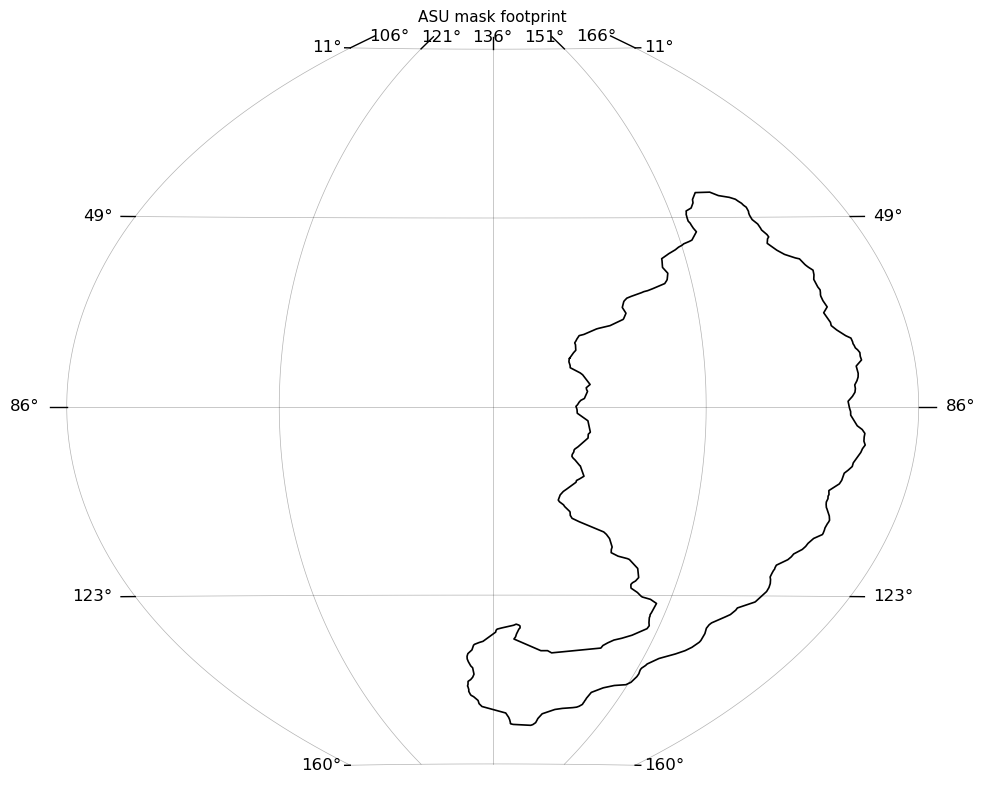

In [18]:
plot_model_mask_hammer(
    asu_mask,
    title="ASU mask footprint",
    theta_lim=(0.2, 2.8),
    phi_lim=(1.85, 2.9),
)


(<Figure size 1000x800 with 2 Axes>,
 <Axes: title={'center': 'Outer leaflet mean curvature'}>)

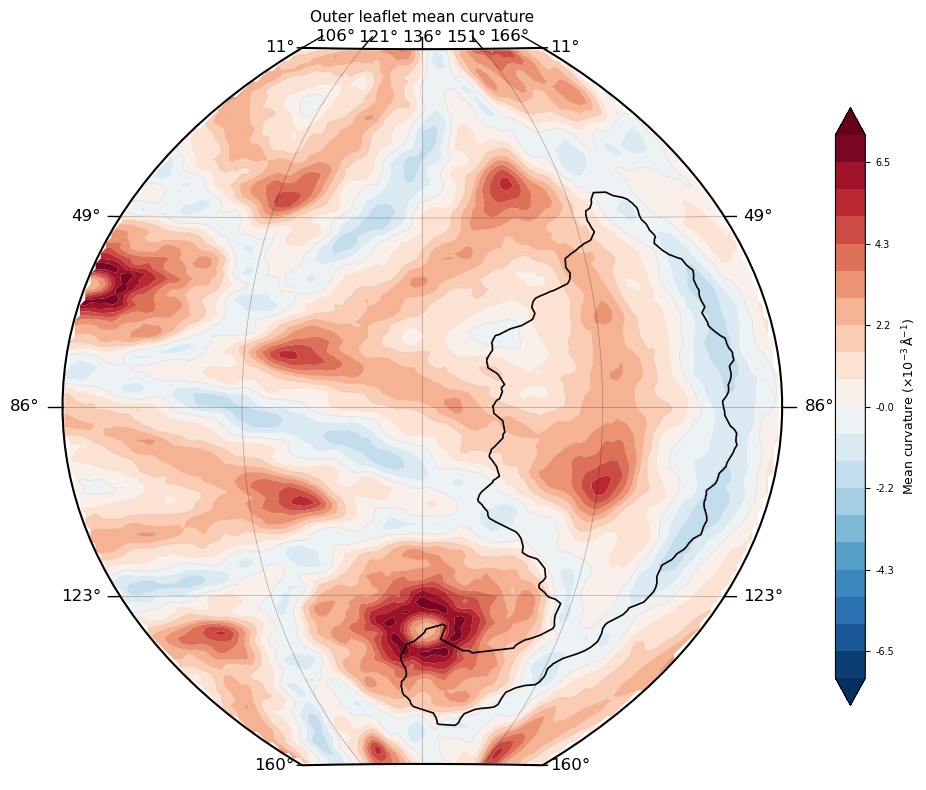

In [19]:
plot_membrane_hammer(
    membrane,
    value_col="mean_curvature",
    leaflet="outer",
    title="Outer leaflet mean curvature",
    theta_lim=(0.2, 2.8),
    phi_lim=(1.85, 2.9),
    overlay_mask=asu_mask,
)
